Exo 1



In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error

In [2]:
from google.colab import files

uploaded = files.upload()

Saving household_power_consumption.txt to household_power_consumption (3).txt


In [3]:
# Show the first few lines of the file
household_power_consumption = list(uploaded.keys())[0]  # to get the uploaded filename
with open(household_power_consumption, "r") as file:
    for _ in range(5):
        print(file.readline())

Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3

16/12/2006;17:24:00;4.216;0.418;234.840;18.400;0.000;1.000;17.000

16/12/2006;17:25:00;5.360;0.436;233.630;23.000;0.000;1.000;16.000

16/12/2006;17:26:00;5.374;0.498;233.290;23.000;0.000;2.000;17.000

16/12/2006;17:27:00;5.388;0.502;233.740;23.000;0.000;1.000;17.000



In [4]:
import pandas as pd

df = pd.read_csv(household_power_consumption)  # Load as a CSV file
df.to_csv("household_power_consumption.csv", index=False)  # Save as a CSV file

In [5]:
# To load the dataset correctly (fixing the separator issue)
df = pd.read_csv("household_power_consumption.csv", sep=";")  # Now columns are separated properly

df.head()

<ipython-input-5-42515a87ea37>:2: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("household_power_consumption.csv", sep=";")  # Now columns are separated properly


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [6]:
# Check the data types of each column
print("Data Types:")
print(df.dtypes)

# Get the shape of the dataset (rows, columns)
print("\nShape of Dataset:")
print(df.shape)

Data Types:
Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object

Shape of Dataset:
(2075259, 9)


In [7]:
# Exercise 2: Handling Missing Values

# Checks for missing values in each column
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64


In [8]:
# # Convert numeric columns from object to float (because they are currently text)
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [9]:
# Fill missing values with the mean of each column
# df.fillna(df.mean(), inplace=True)

In [11]:
# import numpy as np

# # Fill missing values column by column using NumPy (much faster)
# for col in cols_to_convert:
#     mean_value = np.nanmean(df[col])  # Compute mean ignoring NaNs
#     df[col] = np.where(df[col].isna(), mean_value, df[col])


NameError: name 'cols_to_convert' is not defined

In [12]:
df.fillna(method='ffill', inplace=True)  # Forward fill: replaces NaN with the last known value

<ipython-input-12-8567a3072357>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)  # Forward fill: replaces NaN with the last known value


In [ ]:
# Exercise 3: Data Visualization

In [13]:
# Convert 'Date' and 'Time' into a single DateTime column
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

# Set it as the index
df.set_index('DateTime', inplace=True)


In [14]:
# Resampling and Calculating Sum & Mean
# resample the Global_active_power column by day:

# Convert 'Global_active_power' to numeric if it's still an object
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

# Resample by day and calculate sum & mean
daily_power = df.resample('D')['Global_active_power'].agg(['sum', 'mean'])

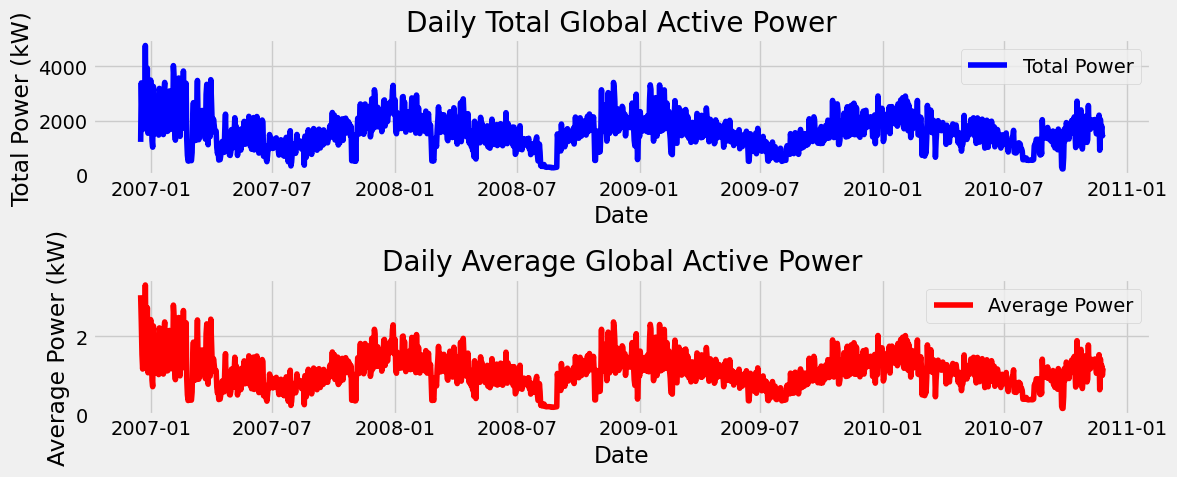

In [15]:
# Plotting the data

# Plot sum and mean of daily Global Active Power
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)  # First subplot (Sum)
plt.plot(daily_power.index, daily_power['sum'], label='Total Power', color='blue')
plt.xlabel('Date')
plt.ylabel('Total Power (kW)')
plt.title('Daily Total Global Active Power')
plt.legend()

plt.subplot(2, 1, 2)  # Second subplot (Mean)
plt.plot(daily_power.index, daily_power['mean'], label='Average Power', color='red')
plt.xlabel('Date')
plt.ylabel('Average Power (kW)')
plt.title('Daily Average Global Active Power')
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
# Resample ‘Global_intensity’ and Calculate Mean & Standard Deviation

# Converting 'Global_intensity' to numeric if it's still an object
df['Global_intensity'] = pd.to_numeric(df['Global_intensity'], errors='coerce')

# Resample Global_intensity by day and calculate mean & standard deviation
daily_intensity = df.resample('D')['Global_intensity'].agg(['mean', 'std'])


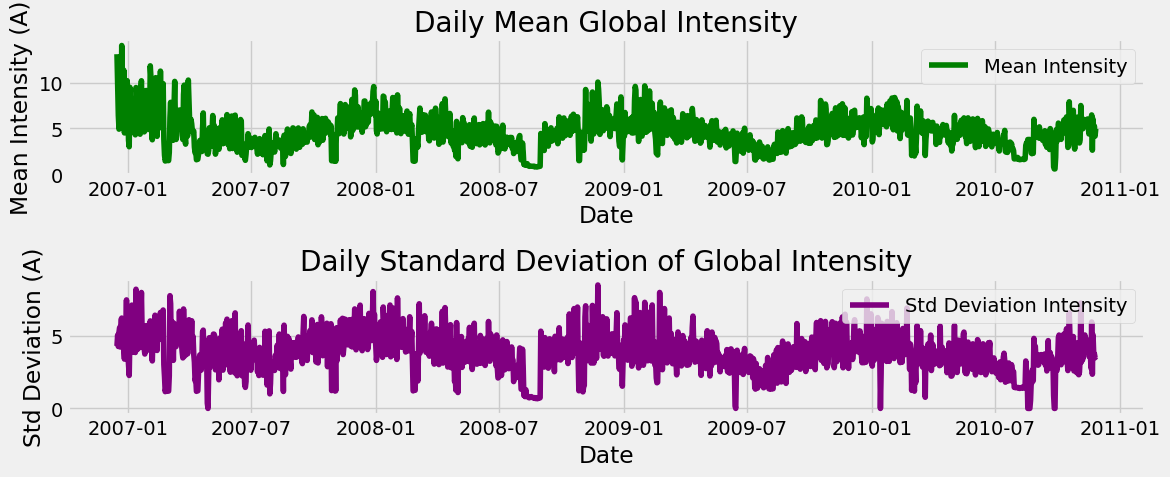

In [18]:
# Plot mean and standard deviation of daily Global Intensity
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)  # First subplot (Mean)
plt.plot(daily_intensity.index, daily_intensity['mean'], label='Mean Intensity', color='green')
plt.xlabel('Date')
plt.ylabel('Mean Intensity (A)')
plt.title('Daily Mean Global Intensity')
plt.legend()

plt.subplot(2, 1, 2)  # Second subplot (Standard Deviation)
plt.plot(daily_intensity.index, daily_intensity['std'], label='Std Deviation Intensity', color='purple')
plt.xlabel('Date')
plt.ylabel('Std Deviation (A)')
plt.title('Daily Standard Deviation of Global Intensity')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Exercise 4: Data Preprocessing for LSTM

In [19]:
# Normalizing the dataset (LSTMs work best when data is scaled between 0 and 1)

# Select the features we need for LSTM (e.g., Global_active_power)
features = ['Global_active_power']

# Initialize MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

# Apply scaler to selected features
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

# Display first few rows after normalization
df_scaled.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
DateTime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,0.374796,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,0.478363,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,0.479631,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,0.480898,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,0.325005,0.528,235.68,15.8,0.0,1.0,17.0


In [20]:
# Splitting the dataset into training and testing sets (80% for training and 20% for testing)

# Define training size (80% of data)
train_size = int(len(df_scaled) * 0.8)

# Split into train and test sets
train_data = df_scaled.iloc[:train_size]
test_data = df_scaled.iloc[train_size:]

# Convert to NumPy arrays (needed for LSTM)
train_values = train_data[features].values
test_values = test_data[features].values

# Print shapes
print("Training data shape:", train_values.shape)
print("Testing data shape:", test_values.shape)

Training data shape: (1660207, 1)
Testing data shape: (415052, 1)


In [21]:
# Reshaping the data for LSTM (LSTMs expect 3D input: (samples, time steps, features))

def create_sequences(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])  # Last 60 steps
        y.append(data[i+time_steps])  # Target value
    return np.array(X), np.array(y)

# Create sequences for LSTM
time_steps = 60
X_train, y_train = create_sequences(train_values, time_steps)
X_test, y_test = create_sequences(test_values, time_steps)

# Reshape for LSTM input (samples, time steps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Print new shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1660147, 60, 1)
X_test shape: (414992, 60, 1)


In [ ]:
# Exercise 5: Building an LSTM Model

In [22]:
# Defining the LSTM Model Architecture

# Build the LSTM model
model = Sequential()

# First LSTM layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))  # Drop 20% of neurons to prevent overfitting

# Second LSTM layer
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Third LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Dense layer (fully connected)
model.add(Dense(units=25))

# Output layer
model.add(Dense(units=1))  # Predict 1 value

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,101 (203.52 KB)

 Trainable params: 52,101 (203.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Exercise 6: Training and Evaluating the LSTM Model

In [24]:
# Training the LSTM model
# history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))
# Train the LSTM model

Epoch 1/10
 6497/25940 ━━━━━━━━━━━━━━━━━━━━ 32:22 100ms/step - loss: 0.0012

KeyboardInterrupt: 

In [ ]:
# ******************I'm Reducing Dataset Size because it's taking too much time to train*******************

In [25]:
# Before splitting into training and test sets, i'm taking a 10% random sample of the dataset

df_sample = df.sample(frac=0.1, random_state=42)  # Take 10% of the data

In [26]:
# df_sample instead of df for normalization, splitting, and LSTM input

# Normalizing using the sampled dataset
df_sample_scaled = df_sample.copy()
df_sample_scaled[features] = scaler.fit_transform(df_sample[features])

# Split into training and test sets
train_size = int(len(df_sample_scaled) * 0.8)
train_data = df_sample_scaled.iloc[:train_size]
test_data = df_sample_scaled.iloc[train_size:]


In [28]:
# Use the sampled dataset instead of the full dataset
df_sample_scaled = df_sample.copy()
df_sample_scaled[features] = scaler.fit_transform(df_sample[features])

# Split into training and testing sets
train_size = int(len(df_sample_scaled) * 0.8)
train_data = df_sample_scaled.iloc[:train_size]
test_data = df_sample_scaled.iloc[train_size:]

# Convert to NumPy arrays
train_values = train_data[features].values
test_values = test_data[features].values

# Create sequences for LSTM
time_steps = 60
X_train, y_train = create_sequences(train_values, time_steps)
X_test, y_test = create_sequences(test_values, time_steps)

# Reshape for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [29]:
# Train LSTM model on the sampled data
history = model.fit(X_train, y_train, epochs=2, batch_size=64, validation_data=(X_test, y_test))


Epoch 1/2
2594/2594 ━━━━━━━━━━━━━━━━━━━━ 262s 101ms/step - loss: 0.0101 - val_loss: 0.0101
Epoch 2/2
2594/2594 ━━━━━━━━━━━━━━━━━━━━ 261s 101ms/step - loss: 0.0100 - val_loss: 0.0101


In [30]:
# Evaluating the Model

# Make predictions
y_pred = model.predict(X_test)

# Inverse transform the predictions to the original scale
y_pred_original = scaler.inverse_transform(y_pred)
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

1296/1296 ━━━━━━━━━━━━━━━━━━━━ 28s 21ms/step


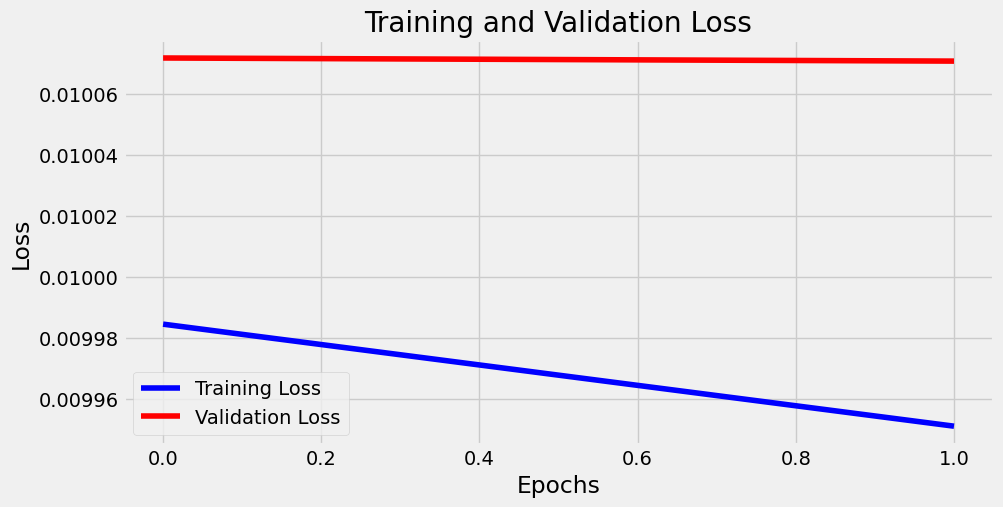

In [31]:
# Plotting Training & Validation Loss

import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

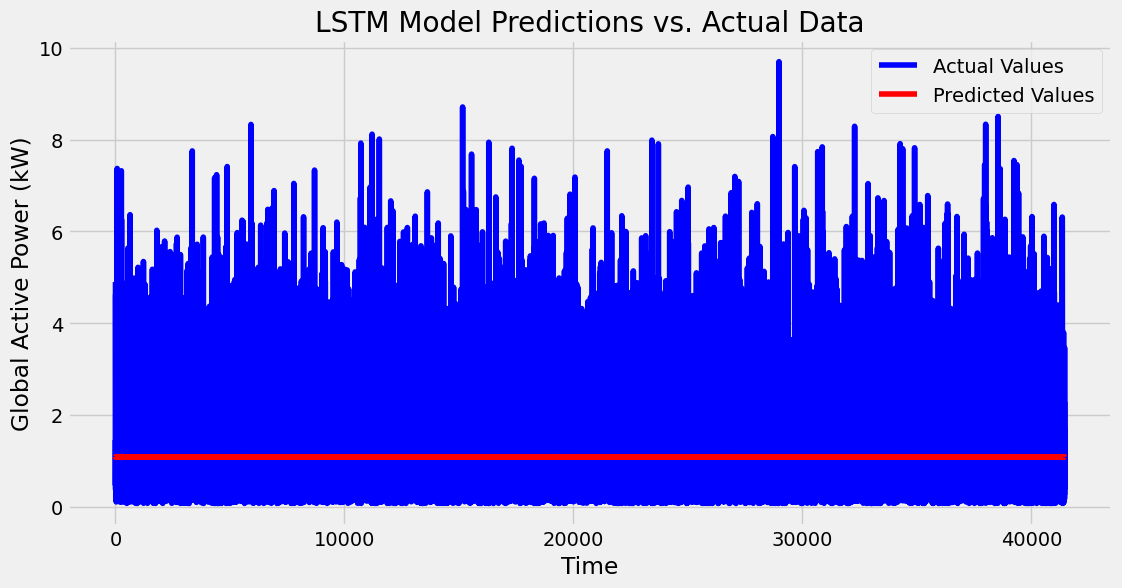

In [32]:
# Plotting Predictions vs. Real Values (actual vs. predicted values)

plt.figure(figsize=(12, 6))

plt.plot(y_test_original, label="Actual Values", color='blue')
plt.plot(y_pred_original, label="Predicted Values", color='red')

plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.title('LSTM Model Predictions vs. Actual Data')
plt.legend()
plt.show()

In [33]:
# Calculating Model Performance (RMSE)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Lower RMSE = Better predictions
# Higher RMSE = Model needs improvement

Root Mean Squared Error (RMSE): 1.0609


In [ ]:
# RMSE ~1 is good if the power values range from 0 to 10 kW (low relative error).